In [1]:
# Hello World & Basic Prints
print("Hello World!")
print(123)
print("Age:", 30)
print("2025","11","17",sep='-')

Hello World!
123
Age: 30
2025-11-17


In [2]:
# Multiline printing
print("Line 1")
print("Line 2")
print("Line 3")
print("Line A\nLine B\nLine C")
multiline = '''This is line 1
This is line 2
This is line 3'''
print(multiline)

Line 1
Line 2
Line 3
Line A
Line B
Line C
This is line 1
This is line 2
This is line 3


In [3]:
# String concatenation
name="Alice"
age=25
print("Hello "+name+"!")
print("Age: "+str(age))
print(f"{name} is {age} years old.")

Hello Alice!
Age: 25
Alice is 25 years old.


In [4]:
# Variables, types, casting
x=5; y=2.5; s="text"
print(type(x), type(y), type(s))
print(int(3.7), float("2.5"), str(100))

<class 'int'> <class 'float'> <class 'str'>
3 2.5 100


In [5]:
# Operators
print(2+3, 5-1, 4*3, 7/2, 7//2, 7%2, 2**3)
print(2+3*4)
print((2+3)*4)

5 4 12 3.5 3 1 8
14
20


In [6]:
# Installing & importing libraries
# !pip install numpy pandas scipy simpy matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline

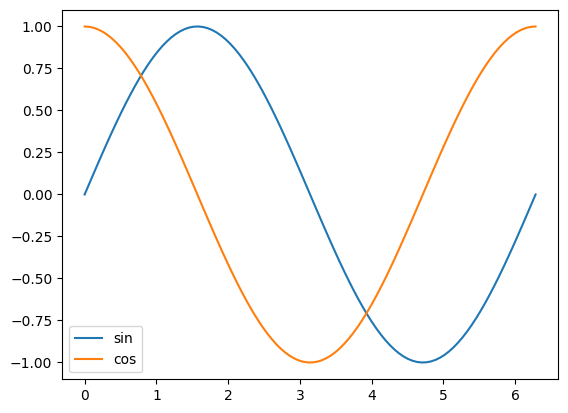

In [7]:
# Matplotlib visualization
x=np.linspace(0,2*np.pi,100)
plt.plot(x,np.sin(x),label='sin')
plt.plot(x,np.cos(x),label='cos')
plt.legend()
plt.show()

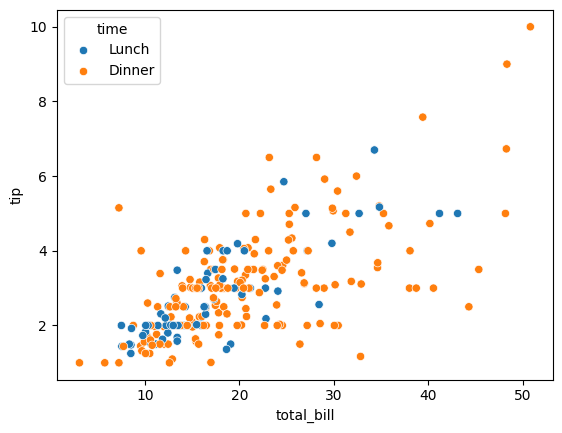

In [8]:
# Seaborn example
tips=sns.load_dataset("tips")
sns.scatterplot(data=tips,x="total_bill",y="tip",hue="time")
plt.show()

In [9]:
# NumPy examples
a=np.array([1,2,3,4])
b=np.array([[1,2,3],[4,5,6]])
print(a)
print(b)
print(b.shape, b.ndim)

zeros=np.zeros((3,3))
print("Zeros:\n",zeros)

c=np.arange(12).reshape(3,4)
print("Reshaped:\n",c)

A=np.array([[1,2],[3,4]])
B=np.array([[5,6],[7,8]])
print("A@B:\n",A@B)

data=np.random.randn(1000)
print(np.mean(data), np.std(data))

[1 2 3 4]
[[1 2 3]
 [4 5 6]]
(2, 3) 2
Zeros:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Reshaped:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
A@B:
 [[19 22]
 [43 50]]
-0.0017278558211799187 1.024885041735022


In [10]:
# SciPy examples
from scipy import integrate, linalg
f=lambda x: np.sin(x)
res,err=integrate.quad(f,0,np.pi)
print("Integral:",res)

A=np.array([[1,2],[3,4]])
print("Determinant:", linalg.det(A))

Integral: 2.0
Determinant: -2.0


In [1]:
!pip install tqdm

Training XOR: 100%|██████████| 400/400 [00:00<00:00, 962.73it/s]


Saved xor_full_combined.gif

--- XOR TESTING AFTER TRAINING ---
[0 0] -> 0.1692
[0 1] -> 0.8443
[1 0] -> 0.8658
[1 1] -> 0.1451

Truth: [0 1 1 0]
Pred : [0. 1. 1. 0.]

🎉 Neural Network has learned XOR!


/tmp/ipython-input-2164203616.py:201: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val = float(o[0])


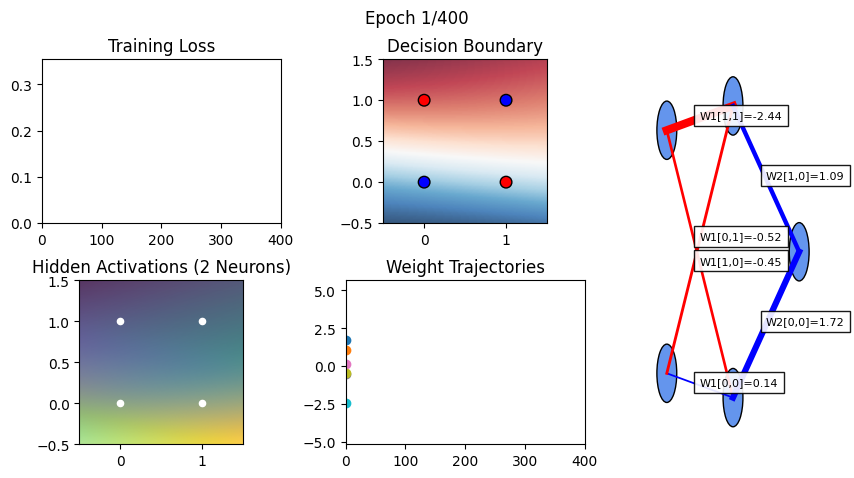

In [10]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# -------------------------------------------------------------------
# DATA
# -------------------------------------------------------------------
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])  # XOR

rng = np.random.default_rng(2)

# -------------------------------------------------------------------
# NETWORK INIT (2-2-1)
# -------------------------------------------------------------------
W1 = rng.normal(0, 1, (2, 2)) * 1.0
b1 = np.zeros((1, 2))
W2 = rng.normal(0, 1, (2, 1)) * 1.0
b2 = np.zeros((1, 1))

def sigmoid(z): return 1/(1+np.exp(-z))
def sigmoid_deriv(z):
    s = sigmoid(z)
    return s*(1-s)

lr = 1.0
epochs = 400

loss_hist=[]
boundary_frames=[]
hidden_frames=[]
weight_paths=[]
snapshots=[]

# Grid for decision boundary
gx = np.linspace(-0.5,1.5,120)
gy = np.linspace(-0.5,1.5,120)
Gx, Gy = np.meshgrid(gx, gy)
G = np.column_stack([Gx.ravel(), Gy.ravel()])

# -------------------------------------------------------------------
# TRAINING WITH PROGRESS BAR
# -------------------------------------------------------------------
for ep in tqdm(range(epochs), desc="Training XOR"):
    # forward
    z1 = X@W1+b1
    a1 = sigmoid(z1)
    z2 = a1@W2+b2
    a2 = sigmoid(z2)
    loss = np.mean((a2-y)**2)
    loss_hist.append(loss)

    # backward
    d2 = (a2-y)*sigmoid_deriv(z2)
    dW2 = a1.T@d2
    db2 = d2.sum(0,keepdims=True)

    d1 = (d2@W2.T)*sigmoid_deriv(z1)
    dW1 = X.T@d1
    db1 = d1.sum(0,keepdims=True)

    W2 -= lr*dW2
    b2 -= lr*db2
    W1 -= lr*dW1
    b1 -= lr*db1

    snapshots.append((W1.copy(), W2.copy(), b1.copy(), b2.copy()))
    weight_paths.append(np.concatenate([W1.ravel(), W2.ravel()]))

    # DECISION BOUNDARY
    H = sigmoid(G@W1+b1)
    YP = sigmoid(H@W2+b2)
    YP = YP.reshape(Gx.shape)
    m, M = YP.min(), YP.max()
    if M-m < 1e-6: M = m + 1e-6
    boundary_frames.append((YP-m)/(M-m))

    # HIDDEN ACTIVATIONS
    h0 = H[:,0].reshape(Gx.shape)
    h1 = H[:,1].reshape(Gx.shape)
    hidden_frames.append([h0, h1])

boundary_frames = np.array(boundary_frames)
hidden_frames = np.array(hidden_frames)
weight_paths = np.array(weight_paths)

# -------------------------------------------------------------------
# FIGURE SETUP
# -------------------------------------------------------------------
fig = plt.figure(figsize=(10,5))
gs = fig.add_gridspec(2,3,width_ratios=[1,1,0.7], wspace=0.3, hspace=0.35)

ax_loss     = fig.add_subplot(gs[0,0])
ax_bound    = fig.add_subplot(gs[0,1])
ax_hidden   = fig.add_subplot(gs[1,0])
ax_weights  = fig.add_subplot(gs[1,1])
ax_net      = fig.add_subplot(gs[:,2])
ax_net.axis("off")

# ---------------- LOSS ----------------
line_loss, = ax_loss.plot([], [])
ax_loss.set_title("Training Loss")
ax_loss.set_xlim(0, epochs)
ax_loss.set_ylim(0, max(loss_hist)*1.1)

# ---------------- DECISION BOUNDARY ----------------
ax_bound.set_title("Decision Boundary")
ax_bound.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="bwr", s=70, edgecolor="k")
db_im = ax_bound.imshow(boundary_frames[0], extent=[gx.min(), gx.max(),
                    gy.min(), gy.max()], origin="lower", cmap="RdBu", vmin=0, vmax=1, alpha=0.80)

# ---------------- HIDDEN ACTIVATIONS ----------------
ax_hidden.set_title("Hidden Activations (2 Neurons)")
im_h0 = ax_hidden.imshow(hidden_frames[0][0], extent=[gx.min(), gx.max(),
                    gy.min(), gy.max()], origin="lower", cmap="viridis", alpha=0.7)
im_h1 = ax_hidden.imshow(hidden_frames[0][1], extent=[gx.min(), gx.max(),
                    gy.min(), gy.max()], origin="lower", cmap="inferno", alpha=0.3)
ax_hidden.scatter(X[:,0], X[:,1], c="white", s=20)

# ---------------- WEIGHT TRAJECTORIES ----------------
ax_weights.set_title("Weight Trajectories")
num_weights = weight_paths.shape[1]
weight_lines = [ax_weights.plot([], [], lw=1, alpha=0.6)[0] for _ in range(num_weights)]
weight_markers = [ax_weights.plot([], [], "o", markersize=6)[0] for _ in range(num_weights)]
ax_weights.set_xlim(0, epochs)
ax_weights.set_ylim(np.min(weight_paths)*1.1, np.max(weight_paths)*1.1)

# ---------------- NEURAL NETWORK DIAGRAM ----------------
def node(ax, xy):
    c = plt.Circle(xy, 0.06, color="cornflowerblue", ec="k")
    ax.add_patch(c)
    return c

node_in  = [(0.1,0.25),(0.1,0.75)]
node_hid = [(0.5,0.2),(0.5,0.8)]
node_out = [(0.9,0.5)]
nodes = [node(ax_net,p) for p in node_in + node_hid + node_out]

edges = [
    (node_in[0], node_hid[0], ("W1",0,0)),
    (node_in[0], node_hid[1], ("W1",0,1)),
    (node_in[1], node_hid[0], ("W1",1,0)),
    (node_in[1], node_hid[1], ("W1",1,1)),
    (node_hid[0], node_out[0], ("W2",0,0)),
    (node_hid[1], node_out[0], ("W2",1,0))
]

lines = []
labels = []
for (s,e,w) in edges:
    ln = ax_net.plot([s[0], e[0]], [s[1], e[1]], lw=1, color='gray')[0]
    lines.append(ln)
    mx, my = (s[0]+e[0])/2, (s[1]+e[1])/2
    txt = ax_net.text(mx, my, "", fontsize=8, bbox=dict(facecolor="white", alpha=0.9))
    labels.append(txt)

# -------------------------------------------------------------------
# UPDATE FUNCTION
# -------------------------------------------------------------------
def update(frame):
    # Loss, decision boundary, hidden
    line_loss.set_data(np.arange(frame+1), loss_hist[:frame+1])
    db_im.set_data(boundary_frames[frame])
    im_h0.set_data(hidden_frames[frame][0])
    im_h1.set_data(hidden_frames[frame][1])

    # Update weight lines and balls
    for i in range(num_weights):
        weight_lines[i].set_data(np.arange(frame+1), weight_paths[:frame+1, i])
        weight_markers[i].set_data([frame], [weight_paths[frame, i]])  # <- wrap in lists

    # Neural network diagram edges
    W1f, W2f, b1f, b2f = snapshots[frame]
    for idx, (s,e,(m,i,j)) in enumerate(edges):
        val = W1f[i,j] if m=="W1" else W2f[i,j]
        labels[idx].set_text(f"{m}[{i},{j}]={val:.2f}")
        lines[idx].set_linewidth(1+abs(val)*2)
        lines[idx].set_color("blue" if val>=0 else "red")

    fig.suptitle(f"Epoch {frame+1}/{epochs}")
    return [line_loss, db_im, im_h0, im_h1] + weight_lines + weight_markers + lines + labels

# -------------------------------------------------------------------
# GENERATE GIF
# -------------------------------------------------------------------
frames_to_render = np.linspace(0, epochs-1, 300, dtype=int)
anim = FuncAnimation(fig, update, frames=frames_to_render, interval=20)
anim.save("xor_full_combined.gif", writer=PillowWriter(fps=10))
print("Saved xor_full_combined.gif")

# -------------------------------------------------------------------
# TEST NETWORK AFTER TRAINING
# -------------------------------------------------------------------
W1f, W2f, b1f, b2f = snapshots[-1]
print("\n--- XOR TESTING AFTER TRAINING ---")
preds = []
for x in X:
    h = sigmoid(x @ W1f + b1f)
    o = sigmoid(h @ W2f + b2f)
    val = float(o[0])
    preds.append(val)
    print(f"{x} -> {val:.4f}")

print("\nTruth:", y.ravel())
print("Pred :", np.round(preds))
if np.array_equal(np.round(preds), y.ravel()):
    print("\n🎉 Neural Network has learned XOR!")
else:
    print("\n⚠ NN did NOT perfectly learn XOR.")